In [1]:
import os
import numpy as np
import pandas as pd
import torch
import time
import mlflow

from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from sklearn.metrics import f1_score, accuracy_score


from src.resnet import ResNet18
from src.pca import PCATransformer
from src.draw_figures import *
from src.dataloader import CIFARCustom

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mlflow.set_experiment("Total_variance")

seed = 42
target = 9
epoch = 15

%matplotlib inline

%load_ext autoreload
%autoreload 2
%reload_ext autoreload

### Готовим данные:

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


generator = torch.Generator().manual_seed(seed)
os.makedirs(f"./output/{target}", exist_ok=True) 


### То, на чем обучаем resnet, строим pca
train_dataset = CIFARCustom(
    root="./data",
    exclude_class=[target],
    train=True, 
    transform=transform
)

train_size = int(0.8 * len(train_dataset))
val_size = int(0.15 * len(train_dataset))

# выборка для построение PCA пространства, для тренеровки модели разделения
test_size = (len(train_dataset) - train_size - val_size) // 2 
# выбока, которая уйдет в финальный тест нового пайплайна
new_pipeline_test_size = len(train_dataset) - train_size - val_size - test_size


train, val, test, new_pipeline_test = random_split(
    train_dataset, 
    [train_size, val_size, test_size, new_pipeline_test_size], 
    generator=generator
)

train_loader = DataLoader(train, batch_size=64, shuffle=True, num_workers=2, generator=generator)
val_loader   = DataLoader(val, batch_size=64, shuffle=False, num_workers=2, generator=generator)
test_loader = DataLoader(test, batch_size=64, shuffle=False, num_workers=2, generator=generator)

### То, на чем делаем холостой (все классы будует неверные) предикт ради feature layer, на чем обучаем и проводим тесты lda
target_dataset = CIFARCustom(
    root="./data",
    exclude_class=[i for i in range(10) if i != target],
    train=True, 
    transform=transform
)

target_train_size = int(0.85 * len(target_dataset))
target_test_size = (len(target_dataset) - target_train_size)
other = len(target_dataset) - target_train_size - target_test_size

train_target, test_target, other = random_split(
    target_dataset, 
    [target_train_size, target_test_size, other]
)

train_target_loader = DataLoader(train_target, batch_size=64, shuffle=True, num_workers=2, generator=generator)
test_target_loader = DataLoader(test_target, batch_size=64, shuffle=True, num_workers=2, generator=generator)

### То, на чем пробуем новый пайплайн
new_pipeline_loader = DataLoader(new_pipeline_test+test_target, batch_size=64, shuffle=True, num_workers=2, generator=generator)


In [3]:
mlflow.start_run(run_name=f"exclude_class_{target}_epoch{epoch}")

mlflow.log_params({
    "target": target,
    "seed": seed,
})

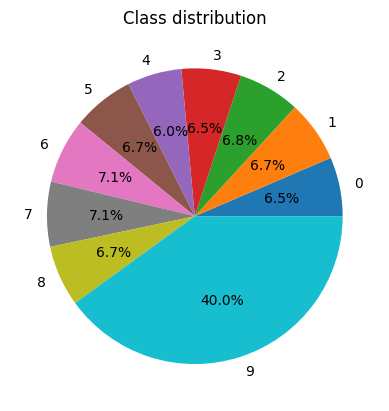

In [4]:
class_distr_path = class_distribution(
    new_pipeline_loader,
    f"output/{target}/new_pipeline_class_distribution.png"
)


mlflow.log_artifact(class_distr_path)

### Подгружаем модель и извлекаем признаки

In [5]:
resnet = ResNet18(
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        device=device,
        learning_rate=0.001,
        # num_epochs=8,
        weights=f"./models/resnet18_cifar10_without{target}_epoch_{epoch}.pth"
    )

# history = resnet.train()

Loaded weights from ./models/resnet18_cifar10_without9_epoch_15.pth


f1-мера (глобальные TP и FP): 0.7292136297454666, 
По каждому классу: [0.8        0.9        0.66932271 0.54723127 0.69230769 0.51923077
 0.80508475 0.78512397 0.84462151]


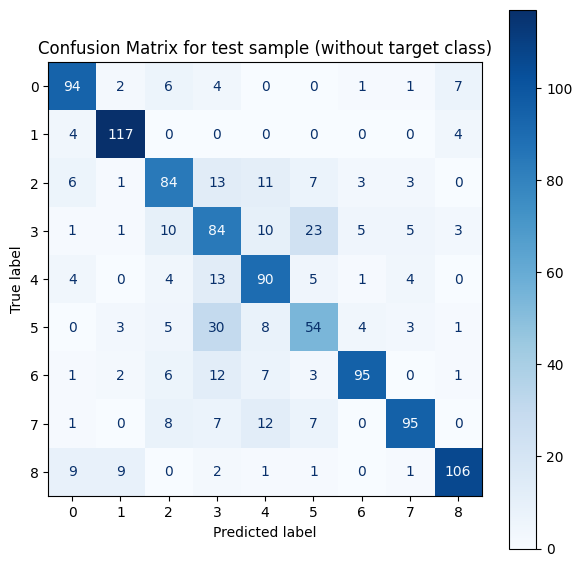

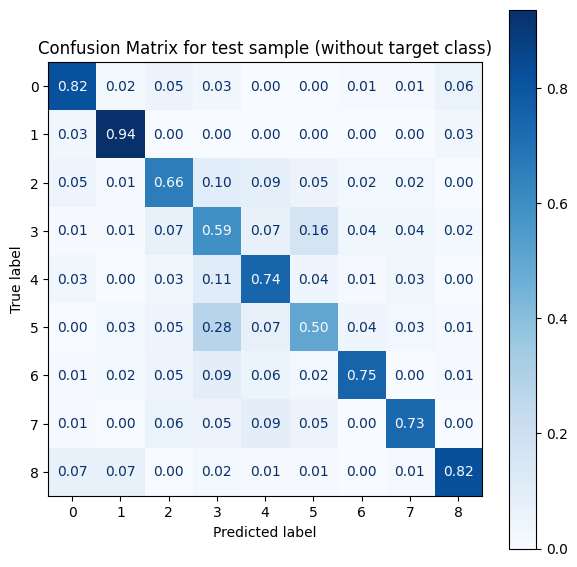

In [6]:
test_cifar9_features, test_cifar9_preds, test_cifar9_gt_preds = resnet.extract_features(test_loader)
test_cifar9_iscorrect = test_cifar9_gt_preds == test_cifar9_preds

mask = test_cifar9_gt_preds == test_cifar9_preds
test_cifar9_CR = test_cifar9_features[mask == True]
test_cifar9_WR = test_cifar9_features[mask == False]

test_cifar9_f1_score =  f1_score(test_cifar9_gt_preds, test_cifar9_preds, average="macro")
test_cifar9_f1_score_list = f1_score(test_cifar9_gt_preds, test_cifar9_preds, average=None)

print("f1-мера (глобальные TP и FP): {}, \nПо каждому классу: {}".format(
        test_cifar9_f1_score,
        test_cifar9_f1_score_list
    )
)
class_names = [str(i) for i in range(10) if i != target]

conf_martix_path = plot_confusion_matrix(
    test_cifar9_preds, 
    test_cifar9_gt_preds, 
    class_names=class_names,
    title="Confusion Matrix for test sample (without target class)",
    path=f"output/{target}/train/confusion_matrix.png"
)

# print(conf_martix_path)

conf_norm_martix_path = plot_confusion_matrix(
    test_cifar9_preds, 
    test_cifar9_gt_preds, 
    class_names=class_names,
    title="Confusion Matrix for test sample (without target class)",
    path=f"output/{target}/train/confusion_norm_matrix.png",
    normalize="true"
)


In [7]:
mlflow.log_artifact(conf_martix_path, artifact_path="Test_loader") 
mlflow.log_artifact(conf_norm_martix_path, artifact_path="Test_loader") 

mlflow.log_metric("test_f1_macro", test_cifar9_f1_score)

for cls, f1 in zip(class_names, test_cifar9_f1_score_list):
        mlflow.log_metric(f"test_f1_class_{cls}", f1)

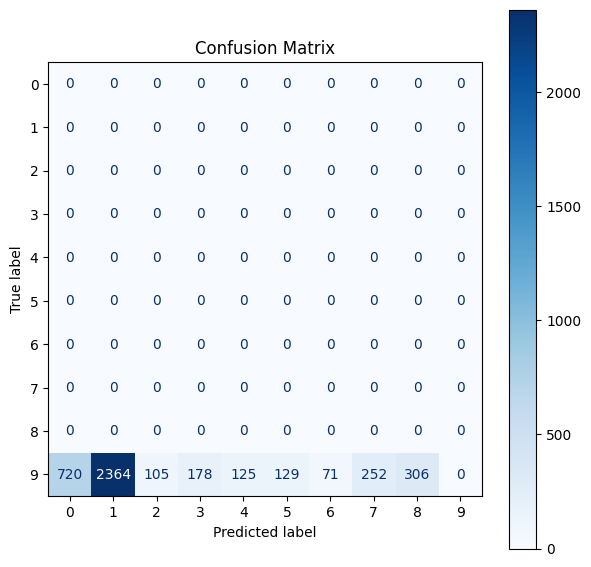

In [8]:
train_target_features, train_target_preds, train_target_gt_preds = resnet.extract_features(train_target_loader)

mask = train_target_gt_preds == train_target_preds
train_target_CR = train_target_features[mask == True]  
train_target_WR = train_target_features[mask == False] 

len(train_target_CR), len(train_target_WR)

plot_confusion_matrix(train_target_preds, train_target_gt_preds)

### Строим новый пайплайн

In [9]:

def new_pipeline(features: np.array, preds: np.array, sep_model, proj):
    features_p = proj.transform(features)


    # se_predict =  np.where(lda.predict_proba(features_p)[:, 1] > thresh, 1, 0)
    sep_predict = sep_model.predict(features_p)

    predict = []
    for i in range(sep_predict.shape[0]):
        if sep_predict[i]:
            predict.append(target)
        else:
            predict.append(preds[i])

    return np.array(predict)

def print_metric(preds, gt_preds):
    # https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html
    new_pipeline_loader_f1_score_macro = f1_score(preds, gt_preds, average="macro")
    new_pipeline_loader_f1_score_micro = f1_score(preds, gt_preds, average="micro")
    new_pipeline_loader_f1_score_list = f1_score(preds, gt_preds, average=None)
    new_pipeline_loader_acc = accuracy_score(preds, gt_preds)

    print("f1-мера (глобальные TP и FP): {} \nf1-score (усреднее): {}" \
    "\nf1-score (по каждому классу): {} \nacc: {}".format(
        new_pipeline_loader_f1_score_macro,
        new_pipeline_loader_f1_score_micro,
        new_pipeline_loader_f1_score_list,
        new_pipeline_loader_acc
        )
    )

    return new_pipeline_loader_f1_score_macro, new_pipeline_loader_f1_score_list

In [10]:
models = {
    "lda": LinearDiscriminantAnalysis(n_components=1),

    "linearSVC": LinearSVC(
        dual=False
    ),

    "logisticRegression": LogisticRegression(
        solver='liblinear'
    ),

    "randomForestClassifier": RandomForestClassifier(
        n_estimators=50,
        max_depth=5,
        random_state=seed,
        n_jobs=-1
    ),

    "xgbClassifier": XGBClassifier(
        n_estimators=20,
        max_depth=4,
        learning_rate=0.05,
        random_state=seed,
        n_jobs=-1
    )
}

In [11]:
pca_full = PCATransformer(
    n_components=100,
    whiten=True
)

pca_full.fit(test_cifar9_features)

Финальное количество главных компонент: 100
Объяснённая дисперсия: 0.985


In [12]:
explained_variance_first_component = round(pca_full.pca.explained_variance_ratio_[0], 3)
stop = round(explained_variance_first_component*100)

mlflow.log_metric("explained_variance_first_component", explained_variance_first_component)
explained_variance_first_component

np.float32(0.414)

In [13]:
features, preds, gt_preds = resnet.extract_features(
    new_pipeline_loader
)

In [14]:
results = []

for variance in range(98, stop-1, -1):
    print(f"\nVariance = {0.99 - variance/100}")

    _, _, tail_variance = pca_full.select_variance_range(
        variance/100,
        0.99
    )

    # tail features
    test_cifar9_CR_tail = pca_full.transform(test_cifar9_CR)
    test_cifar9_WR_tail = pca_full.transform(test_cifar9_WR)
    train_target_p = pca_full.transform(train_target_features)

    print("Tail shape:", test_cifar9_CR_tail.shape)

    # visualization
    # plot_projection(
    #     test_cifar9_CR_tail,
    #     test_cifar9_WR_tail,
    #     path=f"output/{target}/pca/proj_variance{tail_variance}.png"
    # )

    # dataset for separator
    X_pca = np.vstack([
        test_cifar9_CR_tail,
        test_cifar9_WR_tail,
        train_target_p
    ])

    y_pca = np.hstack([
        np.zeros(len(test_cifar9_CR_tail) + len(test_cifar9_WR_tail)),
        np.ones(len(train_target_p))
    ])

    # train + evaluate all models
    for model_name, model in models.items():

        print(f"Training {model_name}")

        model.fit(X_pca, y_pca)

        preds_pca = new_pipeline(
            features,
            preds,
            model,
            pca_full
        )

        f1_macro, f1_list = print_metric(
            preds_pca,
            gt_preds
        )

        results.append({
            "tail_variance": 0.99 - variance/100,
            "model": model_name,
            "f1_macro": f1_macro
        })


Variance = 0.010000000000000009
Выбран диапазон компонент [73:100] (дисперсия: 0.01
Tail shape: (819, 27)
Training lda
f1-мера (глобальные TP и FP): 0.134202465561635 
f1-score (усреднее): 0.4224
f1-score (по каждому классу): [0.13432836 0.1        0.13043478 0.03174603 0.01694915 0.04545455
 0.08510638 0.05797101 0.15827338 0.58176101] 
acc: 0.4224
Training linearSVC
f1-мера (глобальные TP и FP): 0.08477015905003418 
f1-score (усреднее): 0.40746666666666664
f1-score (по каждому классу): [0.06299213 0.         0.07518797 0.         0.         0.
 0.02919708 0.01492537 0.09022556 0.57517348] 
acc: 0.40746666666666664
Training logisticRegression
f1-мера (глобальные TP и FP): 0.1417665587688646 
f1-score (усреднее): 0.4245333333333333
f1-score (по каждому классу): [0.16058394 0.11347518 0.14388489 0.03174603 0.         0.06015038
 0.09859155 0.05797101 0.16901408 0.58224852] 
acc: 0.4245333333333333
Training randomForestClassifier
f1-мера (глобальные TP и FP): 0.05714285714285714 
f1-sco

In [15]:
df = pd.DataFrame(results)

print(df.head())

   tail_variance                   model  f1_macro
0           0.01                     lda  0.134202
1           0.01               linearSVC  0.084770
2           0.01      logisticRegression  0.141767
3           0.01  randomForestClassifier  0.057143
4           0.01           xgbClassifier  0.057143


In [16]:
df.to_csv("data.csv", index=False)

mlflow.log_artifact("data.csv")

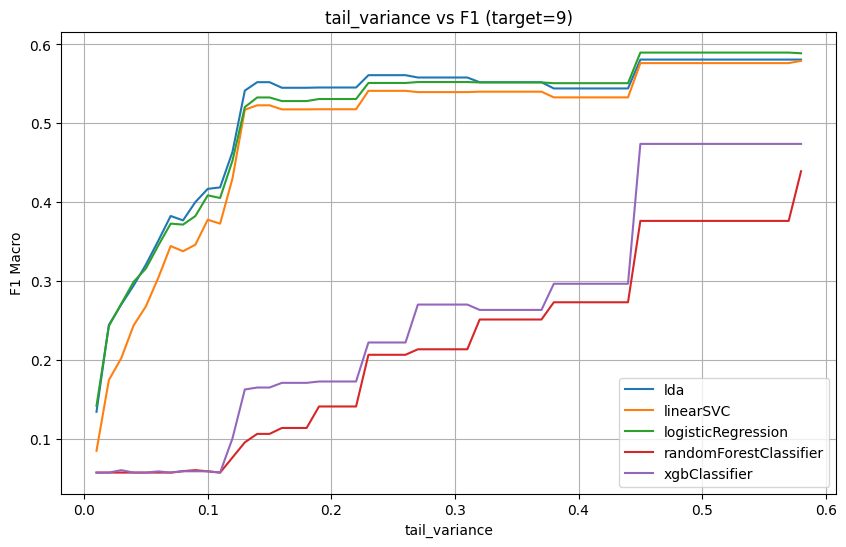

In [17]:

path = plot_variance_vs_f1(
    df, 
    title=f"tail_variance vs F1 (target={target})",
    path=f"output/{target}/variance_vs_f1.png"
)

In [18]:
mlflow.log_artifact(path, "total_tail_variance")

In [19]:
mlflow.end_run()